# Report & Summary Generation

This notebook produces the final **per-polarity report** for a given query.

| Step | What it does |
|---|---|
| 1 | Map 11 emotions → sentiment polarity (positive / negative / neutral) |
| 2 | **Extractive summary** — centroid-nearest tweets per polarity group |
| 3 | **Abstractive summary** — `sshleifer/distilbart-cnn-12-6`, top-10 tweets per group |
| 4 | Formatted report output + saved artefacts |

**Input**: `data/aggregation/retrieved_aggregated.parquet` (from notebook 05)  
**Embeddings**: `data/index/embeddings.npy` (pre-computed corpus embeddings)

## 1. Imports & Configuration

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_DIR   = Path('..').resolve()
AGG_DIR    = BASE_DIR / 'data' / 'aggregation'
INDEX_DIR  = BASE_DIR / 'data' / 'index'
PROC_DIR   = BASE_DIR / 'data' / 'processed'
REPORT_DIR = BASE_DIR / 'data' / 'report'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

EMOTIONS = ['anger', 'anticipation', 'disgust', 'fear', 'joy',
            'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']

# ── Emotion → Polarity mapping ─────────────────────────────────────────────────
POSITIVE_EMOTIONS = {'joy', 'love', 'optimism', 'anticipation', 'trust'}
NEGATIVE_EMOTIONS = {'anger', 'disgust', 'fear', 'pessimism', 'sadness'}
# 'surprise' is ambiguous → goes to neutral

print('Imports done')
print(f'Report artefacts → {REPORT_DIR}')

Imports done
Report artefacts → /home/nasty/Desktop/hua/SocialMediaAgent/data/report


## 2. Load Retrieved Tweets & Corpus Embeddings

In [2]:
# ── Load retrieved (aggregated) tweets from notebook 05 ───────────────────────
df = pd.read_parquet(AGG_DIR / 'retrieved_aggregated.parquet')
print(f'Retrieved tweets : {len(df):,}')
print(f'Columns          : {list(df.columns)}')

QUERY = 'education technology electronics ai'   # same query used in notebook 05
print(f'\nQuery            : "{QUERY}"')

Retrieved tweets : 500
Columns          : ['rank', 'ID', 'Tweet', 'anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust', 'split', 'text_clean', 'text_light', 'n_tokens_clean', 'n_tokens_light', 'hybrid_score', 'cluster', 'umap_x', 'umap_y', 'aspect', 'aspect_score']

Query            : "education technology electronics ai"


In [3]:
# ── Load full corpus embeddings and match to retrieved tweets ─────────────────
corpus = pd.read_parquet(PROC_DIR / 'tweets_processed.parquet').reset_index(drop=True)
all_embeddings = np.load(INDEX_DIR / 'embeddings.npy')   # (10896, 384)

print(f'Corpus size        : {len(corpus):,} tweets')
print(f'Embeddings shape   : {all_embeddings.shape}')

# Build ID → corpus index lookup
id_to_idx = {row['ID']: i for i, row in corpus.iterrows()}

# Map retrieved tweets to their embedding vectors
ret_indices = df['ID'].map(id_to_idx).values
ret_embeddings = all_embeddings[ret_indices]   # (500, 384)

print(f'Retrieved embeddings shape : {ret_embeddings.shape}')
print(f'All IDs resolved           : {len(ret_indices) == len(df)}')

Corpus size        : 10,896 tweets
Embeddings shape   : (10896, 384)
Retrieved embeddings shape : (500, 384)
All IDs resolved           : True


## 3. Sentiment Polarity Assignment

Each tweet receives a **polarity label** based on its active emotions:
- **Positive** — majority of active labels are in {joy, love, optimism, anticipation, trust}
- **Negative** — majority of active labels are in {anger, disgust, fear, pessimism, sadness}
- **Neutral**  — tie, no active emotions, or only *surprise*

In [4]:
def assign_polarity(row) -> str:
    pos_count = sum(row[e] for e in POSITIVE_EMOTIONS if e in row.index)
    neg_count = sum(row[e] for e in NEGATIVE_EMOTIONS if e in row.index)
    if pos_count > neg_count:
        return 'positive'
    elif neg_count > pos_count:
        return 'negative'
    else:
        return 'neutral'

df['polarity'] = df.apply(assign_polarity, axis=1)

polarity_counts = df['polarity'].value_counts()
print('=== Polarity Distribution of Retrieved Tweets ===')
for pol, cnt in polarity_counts.items():
    bar = '█' * (cnt // 5)
    print(f'  {pol:10s}: {cnt:>4}  {bar}')

=== Polarity Distribution of Retrieved Tweets ===
  positive  :  248  █████████████████████████████████████████████████
  negative  :  210  ██████████████████████████████████████████
  neutral   :   42  ████████


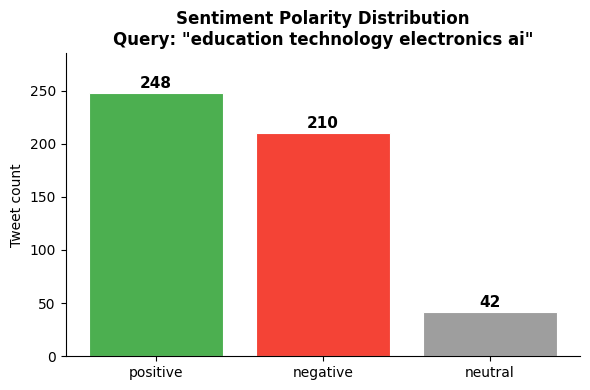

Saved polarity_distribution.png


In [5]:
# ── Visualise polarity distribution ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
colors = {'positive': '#4CAF50', 'negative': '#F44336', 'neutral': '#9E9E9E'}
bars = ax.bar(
    polarity_counts.index,
    polarity_counts.values,
    color=[colors.get(p, '#888') for p in polarity_counts.index],
    edgecolor='white', linewidth=0.8
)
for bar, val in zip(bars, polarity_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title(f'Sentiment Polarity Distribution\nQuery: "{QUERY}"', fontsize=12, fontweight='bold')
ax.set_ylabel('Tweet count')
ax.set_ylim(0, polarity_counts.max() * 1.15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(REPORT_DIR / 'polarity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved polarity_distribution.png')

## 4. Extractive Summary — Centroid-Nearest Tweets

For each polarity group:
1. Compute the **centroid** (mean embedding) of all tweets in that group
2. Rank tweets by cosine similarity to their group centroid
3. Return the **top-N most representative** tweets

In [6]:
def extractive_summary(df_group: pd.DataFrame,
                       group_embeddings: np.ndarray,
                       top_n: int = 3) -> pd.DataFrame:
    """Return the top_n tweets closest to the centroid of the group."""
    if len(df_group) == 0:
        return pd.DataFrame()

    # Centroid of the group
    centroid = group_embeddings.mean(axis=0, keepdims=True)   # (1, 384)

    # Cosine similarity of each tweet to the centroid
    sims = cosine_similarity(group_embeddings, centroid).flatten()   # (N,)

    # Top-N indices (within group)
    top_idxs = np.argsort(sims)[::-1][:top_n]

    result = df_group.iloc[top_idxs].copy()
    result['centroid_sim'] = sims[top_idxs]
    return result[['Tweet', 'polarity', 'centroid_sim', 'hybrid_score'] + EMOTIONS]

In [7]:
# ── Store extractive results per polarity ─────────────────────────────────────
extractive_results = {}

print('=== Extractive Summary — Top-3 Representative Tweets per Polarity ===\n')

for polarity in ['positive', 'negative', 'neutral']:
    mask = df['polarity'] == polarity
    df_pol  = df[mask].reset_index(drop=True)
    emb_pol = ret_embeddings[mask.values]

    if len(df_pol) == 0:
        print(f'[{polarity.upper()}] No tweets found.\n')
        continue

    top_df = extractive_summary(df_pol, emb_pol, top_n=3)
    extractive_results[polarity] = top_df

    print(f'{"═"*65}')
    print(f'  {polarity.upper()}  ({len(df_pol)} tweets in group)')
    print(f'{"═"*65}')
    for _, row in top_df.iterrows():
        active_emo = [e for e in EMOTIONS if row.get(e, 0) == 1]
        print(f'  [sim={row["centroid_sim"]:.3f}] [{", ".join(active_emo) or "none"}]')
        print(f'  {row["Tweet"]}')
        print()

=== Extractive Summary — Top-3 Representative Tweets per Polarity ===

═════════════════════════════════════════════════════════════════
  POSITIVE  (248 tweets in group)
═════════════════════════════════════════════════════════════════
  [sim=0.668] [joy, optimism]
  @edutopia What an innovative way for admin to see what's going on in classrooms! #leadup #awesomeness

  [sim=0.648] [fear, joy, optimism]
  @RJAH_NHS @ChrisHudson76 @mbrandreth #course day # potential Leadership #excited #nervous # proud

  [sim=0.636] [joy, love, optimism]
  We are elated to have @lisavol, Sid Espinosa and @dyuliharris, ready to inspire innovative students!!  @knightfdn @MicrosoftSV @JessicaWeare

═════════════════════════════════════════════════════════════════
  NEGATIVE  (210 tweets in group)
═════════════════════════════════════════════════════════════════
  [sim=0.609] [anger, disgust]
  @FoxNews #Poor = #angry and justly so. Offer people some hope! My god, does anyone see this?! #Education should 

## 5. Abstractive Summary — `sshleifer/distilbart-cnn-12-6`

For each polarity group:
1. Take the **top-10 tweets** (by hybrid retrieval score)
2. Concatenate them with the prompt prefix  
   `"Summarize the following tweets about [query]: ..."`
3. Run through the **DistilBART** summarisation pipeline (offline)

In [8]:
from transformers import pipeline
import torch

DEVICE_ID = 0 if torch.cuda.is_available() else -1
SUMM_MODEL = 'sshleifer/distilbart-cnn-12-6'

print(f'Loading {SUMM_MODEL} ...')
print(f'Device : {"GPU" if DEVICE_ID == 0 else "CPU"}')

summarizer = pipeline(
    'summarization',
    model=SUMM_MODEL,
    device=DEVICE_ID,
    truncation=True,
)
print('Model loaded.')

Loading sshleifer/distilbart-cnn-12-6 ...
Device : GPU


Device set to use cuda:0


Model loaded.


In [9]:
def abstractive_summary(df_group: pd.DataFrame,
                        query: str,
                        top_n: int = 10,
                        max_input_tokens: int = 800,
                        min_length: int = 40,
                        max_length: int = 120) -> str:
    """
    Build a prompt from the top-N tweets (by hybrid_score) and summarise.
    Prompt: 'Summarize the following tweets about [query]: <tweets>'
    """
    if len(df_group) == 0:
        return '(no tweets in this group)'

    # Top-N by retrieval score
    top_tweets = (df_group
                  .sort_values('hybrid_score', ascending=False)
                  .head(top_n)['text_light']
                  .tolist())

    prefix = f'Summarize the following tweets about {query}: '
    body   = ' | '.join(top_tweets)

    # Truncate body so total input stays manageable
    max_body_chars = max_input_tokens * 4   # rough char estimate
    if len(body) > max_body_chars:
        body = body[:max_body_chars]

    prompt = prefix + body

    result = summarizer(
        prompt,
        min_length=min_length,
        max_length=max_length,
        do_sample=False,
    )
    return result[0]['summary_text'].strip()

In [10]:
# ── Run abstractive summaries ──────────────────────────────────────────────────
abstractive_results = {}

print('=== Abstractive Summary per Polarity ===\n')

for polarity in ['positive', 'negative', 'neutral']:
    mask = df['polarity'] == polarity
    df_pol = df[mask].reset_index(drop=True)

    if len(df_pol) == 0:
        abstractive_results[polarity] = '(no tweets in this group)'
        continue

    print(f'Generating summary for [{polarity.upper()}] ({len(df_pol)} tweets)...')
    summary = abstractive_summary(df_pol, query=QUERY)
    abstractive_results[polarity] = summary

    print(f'  → {summary}')
    print()

print('Done.')

=== Abstractive Summary per Polarity ===

Generating summary for [POSITIVE] (248 tweets)...
  → Summarize the following tweets about education technology electronics ai: skillroads . #AI #Resume creator: Take risks: if you win, you will be #happy; if you lose, you'll be wise . #Wisdom #success | #AI#revolation, soon is possible! #Fearless #good #goodness | #ukedchat A4 .

Generating summary for [NEGATIVE] (210 tweets)...
  → Tweets about education technology electronics ai: "What a joke!! Cut our internet off early 'by mistake' and then don't reinstate it when we no longer need an engineer" "My god, does anyone see this?! #Education should not be for the #elite" "IKR? Everyone who still had an analog phone *had* to"

Generating summary for [NEUTRAL] (42 tweets)...
  → Summarize the following tweets about education technology electronics electronics ai: #AI #revolation, soon is possible!\n#fearless #fearful #good #goodness | I want to digital art so bad, but my dad won't let me use my i

## 6. Full Report

In [11]:
from IPython.display import display, HTML

def render_report(query: str,
                  polarity_counts: pd.Series,
                  extractive: dict,
                  abstractive: dict) -> str:
    """Render a styled HTML report and return the HTML string."""

    color_map = {'positive': '#4CAF50', 'negative': '#F44336', 'neutral': '#757575'}
    icon_map  = {'positive': '😊', 'negative': '😠', 'neutral': '😐'}

    html_parts = [f"""
    <div style="font-family: Arial, sans-serif; max-width: 860px; margin: auto;">
    <h2 style="border-bottom: 2px solid #333; padding-bottom: 6px;">
        📋 Social Media Report — <em>{query}</em>
    </h2>
    <p style="color:#555; font-size:13px;">
        Total retrieved: <strong>{sum(polarity_counts)}</strong> tweets &nbsp;|&nbsp;
        { ' &nbsp;|&nbsp; '.join(
            f'<span style="color:{color_map[p]}">{icon_map[p]} {p.capitalize()}: <strong>{polarity_counts.get(p, 0)}</strong></span>'
            for p in ['positive', 'negative', 'neutral']
        ) }
    </p>
    """]

    for polarity in ['positive', 'negative', 'neutral']:
        color = color_map[polarity]
        icon  = icon_map[polarity]
        count = polarity_counts.get(polarity, 0)
        abs_text = abstractive.get(polarity, '—')
        ext_df   = extractive.get(polarity, pd.DataFrame())

        html_parts.append(f"""
        <div style="margin-bottom: 28px;">
        <h3 style="color:{color}; margin-bottom: 4px;">{icon} {polarity.capitalize()} ({count} tweets)</h3>

        <div style="background: dark-grey; border-left: 4px solid {color};
                    padding: 10px 16px; border-radius: 4px; margin-bottom: 12px;">
            <strong>Abstractive Summary</strong><br>
            <span style="font-size: 14px; line-height: 1.6;">{abs_text}</span>
        </div>

        <strong>Extractive Summary — 3 most representative tweets</strong>
        <table style="width:100%; border-collapse: collapse; font-size:13px; margin-top:6px;">
        <tr style="background:{color}22;">
            <th style="padding:6px 8px; text-align:left; border-bottom:1px solid #ddd;">Tweet</th>
            <th style="padding:6px 8px; text-align:center; border-bottom:1px solid #ddd; white-space:nowrap;">Centroid sim</th>
            <th style="padding:6px 8px; text-align:left; border-bottom:1px solid #ddd;">Active emotions</th>
        </tr>
        """)

        if not ext_df.empty:
            for _, row in ext_df.iterrows():
                active_emo = [e for e in EMOTIONS if row.get(e, 0) == 1]
                emo_str    = ', '.join(active_emo) if active_emo else '—'
                tweet_txt  = str(row['Tweet']).replace('<', '&lt;').replace('>', '&gt;')
                html_parts.append(f"""
                <tr>
                    <td style="padding:6px 8px; border-bottom:1px solid #eee;">{tweet_txt}</td>
                    <td style="padding:6px 8px; text-align:center; border-bottom:1px solid #eee;">{row['centroid_sim']:.3f}</td>
                    <td style="padding:6px 8px; border-bottom:1px solid #eee; color:#555;">{emo_str}</td>
                </tr>""")
        else:
            html_parts.append('<tr><td colspan="3" style="padding:8px; color:#999;">No tweets</td></tr>')

        html_parts.append('</table></div>')

    html_parts.append('</div>')
    return ''.join(html_parts)

html_report = render_report(QUERY, polarity_counts, extractive_results, abstractive_results)
display(HTML(html_report))

Tweet,Centroid sim,Active emotions
@edutopia What an innovative way for admin to see what's going on in classrooms! #leadup #awesomeness,0.668,"joy, optimism"
@RJAH_NHS @ChrisHudson76 @mbrandreth #course day # potential Leadership #excited #nervous # proud,0.648,"fear, joy, optimism"
"We are elated to have @lisavol, Sid Espinosa and @dyuliharris, ready to inspire innovative students!! @knightfdn @MicrosoftSV @JessicaWeare",0.636,"joy, love, optimism"
Tweet,Centroid sim,Active emotions
"@FoxNews #Poor = #angry and justly so. Offer people some hope! My god, does anyone see this?! #Education should not be for the #elite",0.609,"anger, disgust"
@SkyUK what a joke!! Cut our internet off early 'by mistake' and then don't reinstate it when we no longer need an engineer 😡 #fuming,0.568,"anger, disgust"
@TheAnchoredMrs I was the sixth grade teacher this year and last year the the fifth grade teacher who got mad when they did 😂,0.568,"anger, disgust, joy"
Tweet,Centroid sim,Active emotions
@HollyMecher I'm stealing this one 😎🤘🏻👏🏻👏🏻👏🏻👏🏻 #edtechchat,0.558,"anger, joy"
@Jamiebower first second on #WillTNT is music to my ears 😭❤️ #shaking #missedyou,0.554,"love, sadness"


## 7. Emotion Heatmap per Polarity Group

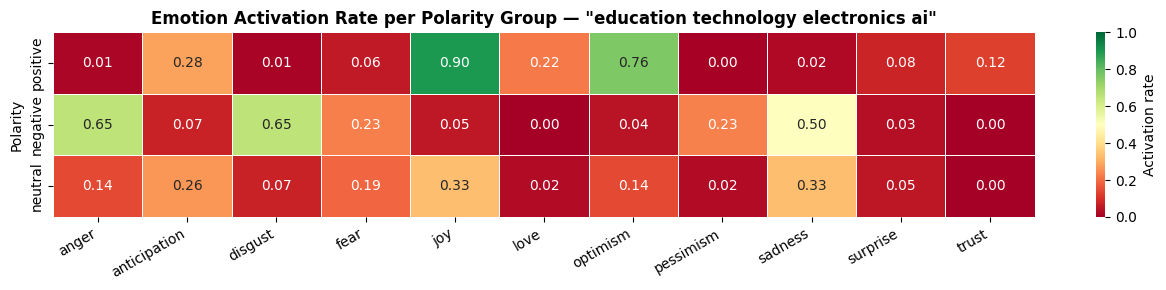

Saved polarity_emotion_heatmap.png


In [12]:
# ── Emotion activation rate per polarity ──────────────────────────────────────
heatmap_data = {}
for polarity in ['positive', 'negative', 'neutral']:
    mask = df['polarity'] == polarity
    df_pol = df[mask]
    if len(df_pol) == 0:
        heatmap_data[polarity] = pd.Series(0.0, index=EMOTIONS)
    else:
        heatmap_data[polarity] = df_pol[EMOTIONS].mean()

heatmap_df = pd.DataFrame(heatmap_data).T   # (3, 11)

fig, ax = plt.subplots(figsize=(13, 3))
sns.heatmap(
    heatmap_df,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.4,
    ax=ax,
    cbar_kws={'label': 'Activation rate'},
    vmin=0, vmax=1,
)
ax.set_title(f'Emotion Activation Rate per Polarity Group — "{QUERY}"',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Polarity')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'polarity_emotion_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved polarity_emotion_heatmap.png')

## 8. Save Report Artefacts

In [13]:
import json

# ── Save abstractive summaries as JSON ────────────────────────────────────────
report_data = {
    'query': QUERY,
    'polarity_counts': polarity_counts.to_dict(),
    'abstractive_summaries': abstractive_results,
}
with open(REPORT_DIR / 'report_summary.json', 'w', encoding='utf-8') as f:
    json.dump(report_data, f, ensure_ascii=False, indent=2)
print('Saved report_summary.json')

# ── Save extractive summaries (merged DataFrame) ──────────────────────────────
ext_frames = []
for polarity, df_ext in extractive_results.items():
    if not df_ext.empty:
        df_ext = df_ext.copy()
        df_ext['polarity_group'] = polarity
        ext_frames.append(df_ext)

if ext_frames:
    df_extractive = pd.concat(ext_frames, ignore_index=True)
    df_extractive.to_parquet(REPORT_DIR / 'extractive_summaries.parquet', index=False)
    print('Saved extractive_summaries.parquet')

# ── Save HTML report ──────────────────────────────────────────────────────────
with open(REPORT_DIR / 'report.html', 'w', encoding='utf-8') as f:
    f.write('<html><head><meta charset="utf-8"></head><body>')
    f.write(html_report)
    f.write('</body></html>')
print('Saved report.html')

# ── List artefacts ────────────────────────────────────────────────────────────
print(f'\nArtefacts in {REPORT_DIR}:')
for p in sorted(REPORT_DIR.iterdir()):
    print(f'  {p.name:45s} {p.stat().st_size/1024:>8.1f} KB')

Saved report_summary.json
Saved extractive_summaries.parquet
Saved report.html

Artefacts in /home/nasty/Desktop/hua/SocialMediaAgent/data/report:
  extractive_summaries.parquet                      10.6 KB
  polarity_distribution.png                         34.3 KB
  polarity_emotion_heatmap.png                      95.4 KB
  report.html                                        8.6 KB
  report_summary.json                                1.1 KB
